
# Network Science - UDD

## Procesos en redes: de la estructura a la dinámica


#### *Cristian Candia-Castro Vallejos, Ph.D.*

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 

---
#### Para ver una heramienta interactiva complementaria de esta clase visitar:


**https://spreading.criss-lab.com/**

---

## Objetivos de aprendizaje

**Foco de la semana:** conectar estructura con dinámica, entender que la "importancia" de un nodo, dependiendo del contexto, también depende del proceso, y comparar intervenciones sobre redes.

Al final de este notebook deberías poder:

1. distinguir entre procesos **SIS** y **SIR** sobre redes;
2. explicar qué significa un **umbral epidémico**;
3. entender la intuición de dos aproximaciones clásicas para el umbral:
   - **HMF** (*heterogeneous mean field*);
   - **espectral / QMF** (radio espectral de la matriz de adyacencia);
4. justificar por qué una red **temporal** no es lo mismo que su versión **agregada**;
5. comparar estrategias de intervención:
   - aleatoria,
   - por grado,
   - por $k$-core;
6. articular una idea central de esta unidad: **la importancia estructural depende del proceso dinámico que está ocurriendo sobre la red**.

---

## Hilo conductor

Hasta ahora hemos estudiado la red como estructura: grado, clustering, distancias, comunidades, núcleos, etc.  
En esta clase damos un paso clave: **la red no es el fin, es el sustrato sobre el cual corre una dinámica**.

Eso cambia la pregunta.

- Antes: “¿qué nodo es más importante?”
- Ahora: “¿más importante para qué proceso?”

No es lo mismo ser importante para:
- difundir una enfermedad
- acelerar el alcance de una noticia
- bloquear una cascada
- mantener conectada una infraestructura

Por eso, en procesos sobre redes, la pregunta correcta no es "qué nodo es importante en general", sino **qué nodo es importante para una dinámica dada y bajo qué horizonte temporal**.

## Qué debe quedar claro

1. La topología de la red no solo describe una red: también cambia velocidad, alcance y persistencia de la difusión.
2. `SIS` y `SIR` responden preguntas distintas y privilegian métricas distintas.
3. El umbral epidémico no pertenece solo a la dinámica ni solo a la red, sino al acoplamiento entre ambas.
4. Las fórmulas tipo `HMF` (campo medio heterogeneo) y espectral son aproximaciones útiles para pensar, no soluciones exactas.
5. La "importancia: de un nodo cambia si queremos maximizar difusión, reducir tamaño final o impedir persistencia.
6. En redes temporales, el orden de los contactos es parte del mecanismo, no un detalle de formato.


## Literatura base usada aquí

La columna vertebral conceptual de esta unidad es:

- **Newman (2002)** para la equivalencia entre `SIR` y percolación.
- **Newman (2010)** para el puente general entre estructura de red y procesos dinámicos.
- **Pastor-Satorras & Vespignani (2001)** para la intuición sobre epidemias en redes heterogéneas.
- **Wang et al. (2003)** para la lectura espectral del umbral.
- **Holme (2015)** para la advertencia metodológica sobre redes temporales.


## Outline

La secuencia está pensada en cuatro movimientos:

1. **Distinguir procesos**: `SIS` vs `SIR`, y qué pregunta responde cada uno.
2. **Formalizar intuiciones**: umbral epidémico, heterogeneidad de grados y radio espectral.
3. **Traducir a decisiones**: qué nodos intervenir y con qué criterio.
4. **Evitar atajos erróneos**: no confundir red agregada con difusión temporal real.

La práctica complementaria está en `Clase6_Procesos_en_Redes_Practica.ipynb`. 

## Convenciones

1. **`SIR` y `SIS` no se mezclan**.  
   `SIR` se usa para tamaño final de brote y percolación; `SIS` se usa para persistencia/endemia y umbral dinámico.

2. **No todos los resultados tienen el mismo estatus lógico**.  
   En esta unidad veremos:
   - resultados **exactos** o muy bien fundados dentro de un modelo concreto;
   - aproximaciones **HMF** o **espectrales**, que son extremadamente útiles, pero siguen siendo aproximaciones.

3. **“No hay umbral” nunca debe decirse sin contexto**.  
   En la literatura clásica eso suele referirse al límite asintótico de ciertas redes heterogéneas y bajo modelos específicos. En redes finitas reales, lo correcto casi siempre es hablar de un **umbral efectivo muy bajo**, no necesariamente cero.

4. **La importancia estructural depende del mecanismo y del criterio de desempeño**.  
   No hay una centralidad universalmente correcta para todos los procesos y todos los objetivos.


## Notación mínima de la unidad

- $\beta$: probabilidad o tasa de transmisión por contacto.
- $\mu$: probabilidad o tasa de recuperación.
- $\lambda = \beta / \mu$: razón efectiva transmisión-recuperación, usada como parámetro de control.
- $T$: **transmissibility**, es decir, probabilidad efectiva de que un enlace transmita a lo largo de todo el periodo infeccioso.
- $\lambda_1(A)$: mayor autovalor de la matriz de adyacencia; resume capacidad de amplificación estructural.
- $\langle k \rangle$: grado medio.
- $\langle k^2 \rangle$: segundo momento de la distribución de grados (varianza); captura heterogeneidad.

---



## 1. Estructura vs dinámica


Una red se puede representar por una matriz de adyacencia $A$, donde $A_{ij}=1$ si existe enlace entre $i$ y $j$.

Pero conocer $A$ no basta. Falta definir **qué regla local gobierna el cambio de estado** de cada nodo.

En epidemias, cada nodo puede estar en alguno de varios estados:

- $S$: susceptible,
- $I$: infectado / infectivo,
- $R$: removido o recuperado con inmunidad.

<img src="img/img1.png" alt="Drawing" style="width: 700px;"/>


El punto central es que **la topología modula las oportunidades de contacto**, y por tanto altera:

- la velocidad de expansión,
- el tamaño final del brote,
- la existencia o no de un umbral,
- la efectividad de una intervención.

En una población bien mezclada todos interactúan potencialmente con todos.  
En una red, en cambio, los contactos están **canalizados** por enlaces concretos. Esto vuelve al problema más realista y, al mismo tiempo, más sensible a la heterogeneidad estructural.

## 2. Modelos microscópicos: SIS y SIR sobre redes

### SIS

En **SIS**, un nodo pasa por:
$$S \to I \to S.$$

Interpretación:
- un susceptible se infecta al contacto con vecinos infectados;
- un infectado se recupera, pero **vuelve a ser susceptible**.

Esto es útil para procesos donde no hay inmunidad duradera:
- ciertos patógenos,
- malware,
- rumores o comportamientos que pueden reaparecer.

### SIR

En **SIR**, un nodo pasa por:
$$S \to I \to R.$$

Interpretación:
- un susceptible se infecta;
- luego sale del proceso activo y ya no vuelve a infectarse.

Esto modela bien:
- enfermedades con inmunidad posterior,
- adopciones irreversibles,
- difusión donde “haber pasado por el estado activo” deja una huella permanente.

---

## Regla microscópica típica

Sea $\beta$ la probabilidad o tasa de transmisión por contacto, y $\mu$ la tasa de recuperación.

- En **SIS**:
  - $S$ se infecta por vecinos $I$ con intensidad controlada por $\beta$;
  - $I$ se recupera a $S$ con tasa $\mu$.

- En **SIR**:
  - $S$ se infecta con $\beta$;
  - $I$ pasa a $R$ con tasa $\mu$.

Muchas veces se resume el balance por el cociente:
$$\lambda = \frac{\beta}{\mu},$$
que actúa como **parámetro de control efectivo**.

## SIS vs SIR comparados

| Aspecto | `SIS` | `SIR` |
|---|---|---|
| Secuencia de estados | $S \to I \to S$ | $S \to I \to R$ |
| Pregunta central | ¿la infección persiste? | ¿qué tan grande es el brote final? |
| Objeto teórico típico | umbral dinámico / prevalencia estacionaria | tamaño final / componente epidémico |
| Herramienta clásica | `HMF`, `QMF`, radio espectral | transmissibility y percolación |
| Intuición estructural clave | hubs y amplificación sostenida | alcance geométrico del brote |
| Lenguaje seguro en clase | persistencia, endemia, prevalencia | brote, alcance, tamaño final |

Regla guía:

- si estás hablando de **persistencia**, probablemente estás en lenguaje `SIS`;
- si estás hablando de **tamaño final**, probablemente estás en lenguaje `SIR`.


### No confundir modelo, simulación y fenómeno

Conviene separar tres niveles:

1. **Fenómeno**: epidemia, rumor, adopción o falla en cascada.
2. **Modelo**: `SIS` o `SIR`, que abstrae estados y transiciones.
3. **Implementación**: la versión concreta que simulamos después en el notebook.

En este material, varias fórmulas teóricas vienen de versiones idealizadas o continuas del proceso, mientras que la simulación usa tiempo discreto, red estática, contactos no ponderados y actualización sincrónica. Si una simulación no coincide exactamente con la intuición analítica, la pregunta correcta es qué supuesto cambió.

---

## 3. Intuición del umbral epidémico

La pregunta central es:

> ¿existe un valor crítico de transmisibilidad tal que, por debajo, el brote muere rápido, y por encima, puede sostenerse o crecer macroscópicamente?

Ese valor es el **umbral epidémico**.

### Intuición tipo branching process

Al inicio del brote, cuando casi todos son susceptibles, cada infectado genera nuevos casos antes de recuperarse. Si en promedio produce más de un nuevo infectado, la epidemia puede sostenerse; si produce menos de uno, tiende a extinguirse.

En redes heterogéneas, este reemplazo no depende sólo de $\beta$ y $\mu$, sino también de:
- cuántos vecinos tiene la gente,
- cómo se distribuyen esos grados,
- si hay hubs,
- si los contactos ocurren al mismo tiempo o en secuencia.

Por eso **el umbral no es una constante universal del proceso**, sino una propiedad conjunta de **dinámica + estructura**.

## 4. Aproximación HMF: el papel de $\langle k^2 \rangle$

Recordemos primero la idea de **mean field**. En lugar de seguir la dinámica exacta nodo a nodo, reemplazamos el vecindario real de cada nodo por un **entorno promedio**. Esa simplificación puede ser razonable cuando los nodos son relativamente parecidos entre sí. Pero en redes heterogéneas esta hipótesis deja de ser convincente: un nodo de grado bajo no enfrenta el mismo riesgo de infección ni tiene la misma capacidad de transmitir que un hub.

<img src="img/img2.png" alt="Drawing" style="width: 800px;"/>


La aproximación **heterogeneous mean field (HMF)**, también llamada **degree-based mean field**, introduce una corrección natural: en vez de tratar a todos los nodos como equivalentes, los **agrupa por grado** y supone que los nodos con el mismo valor de $k$ son estadísticamente equivalentes. Así, la dinámica ya no se describe con una sola variable promedio para toda la red, sino con cantidades del tipo $\rho_k(t)$, que representan la fracción de nodos infectados dentro de la clase de grado $k$.

Para el modelo **SIS** en redes **no correlacionadas**, esta aproximación conduce a una expresión clásica para el umbral epidémico:

$$
\lambda_c^{\mathrm{HMF}} = \frac{\langle k \rangle}{\langle k^2 \rangle}.
$$

Aquí $\langle k \rangle$ es el **grado medio** y $\langle k^2 \rangle$ es el **segundo momento** de la distribución de grados.

Esta fórmula debe interpretarse con cuidado. Es un resultado **analíticamente exacto dentro del cierre HMF**, es decir, dentro de una teoría en la que la dinámica se describe por clases de grado y se asume una red no correlacionada. Pero **no debe entenderse como una identidad universal exacta del proceso SIS microscópico sobre cualquier red finita concreta**. En una red específica, el umbral puede depender también de otros rasgos estructurales que HMF no representa de forma explícita, como correlaciones de grado (asortatividad), clustering, modularidad o propiedades espectrales de la matriz de adyacencia.

>Interpretando la furmula, si la red es muy heterogénea, aparecen hubs importantes y el valor de $\langle k^2 \rangle$ crece mucho. Como $\langle k^2 \rangle$ aparece en el denominador, el umbral predicho por HMF **disminuye**. En ese sentido, la heterogeneidad estructural favorece la persistencia del contagio.

La literatura clásica, en particular Pastor-Satorras y Vespignani, mostró que en redes **scale-free** suficientemente heterogéneas la predicción HMF puede llevar a un umbral que tiende a cero en el límite de tamaño infinito, precisamente cuando $\langle k^2 \rangle$ diverge. Sin embargo, en una red **finita**, $\langle k^2 \rangle$ siempre es finito. Por eso, en contextos empíricos, lo más correcto es hablar de un **umbral efectivo muy pequeño**, y no de la desaparición literal del umbral en cualquier red observada.

>La intuición de fondo es que los hubs facilitan la persistencia de la infección porque tienen muchas oportunidades de adquirirla, muchas oportunidades de transmitirla, y además pueden sostener ciclos locales de reinfección que ayudan a mantener activa la dinámica.

La idea central que deja HMF es, entonces, muy poderosa: **la heterogeneidad de grados modifica de manera cualitativa la epidemiología sobre redes**.


=== Red Erdős–Rényi (más homogénea) ===
<k>     = 5.911
<k^2>   = 40.863
lambda_c^HMF = <k>/<k^2> = 0.144663

=== Red Barabási–Albert (más heterogénea) ===
<k>     = 5.994
<k^2>   = 103.800
lambda_c^HMF = <k>/<k^2> = 0.057746

Razón de umbrales ER / BA:
2.51x


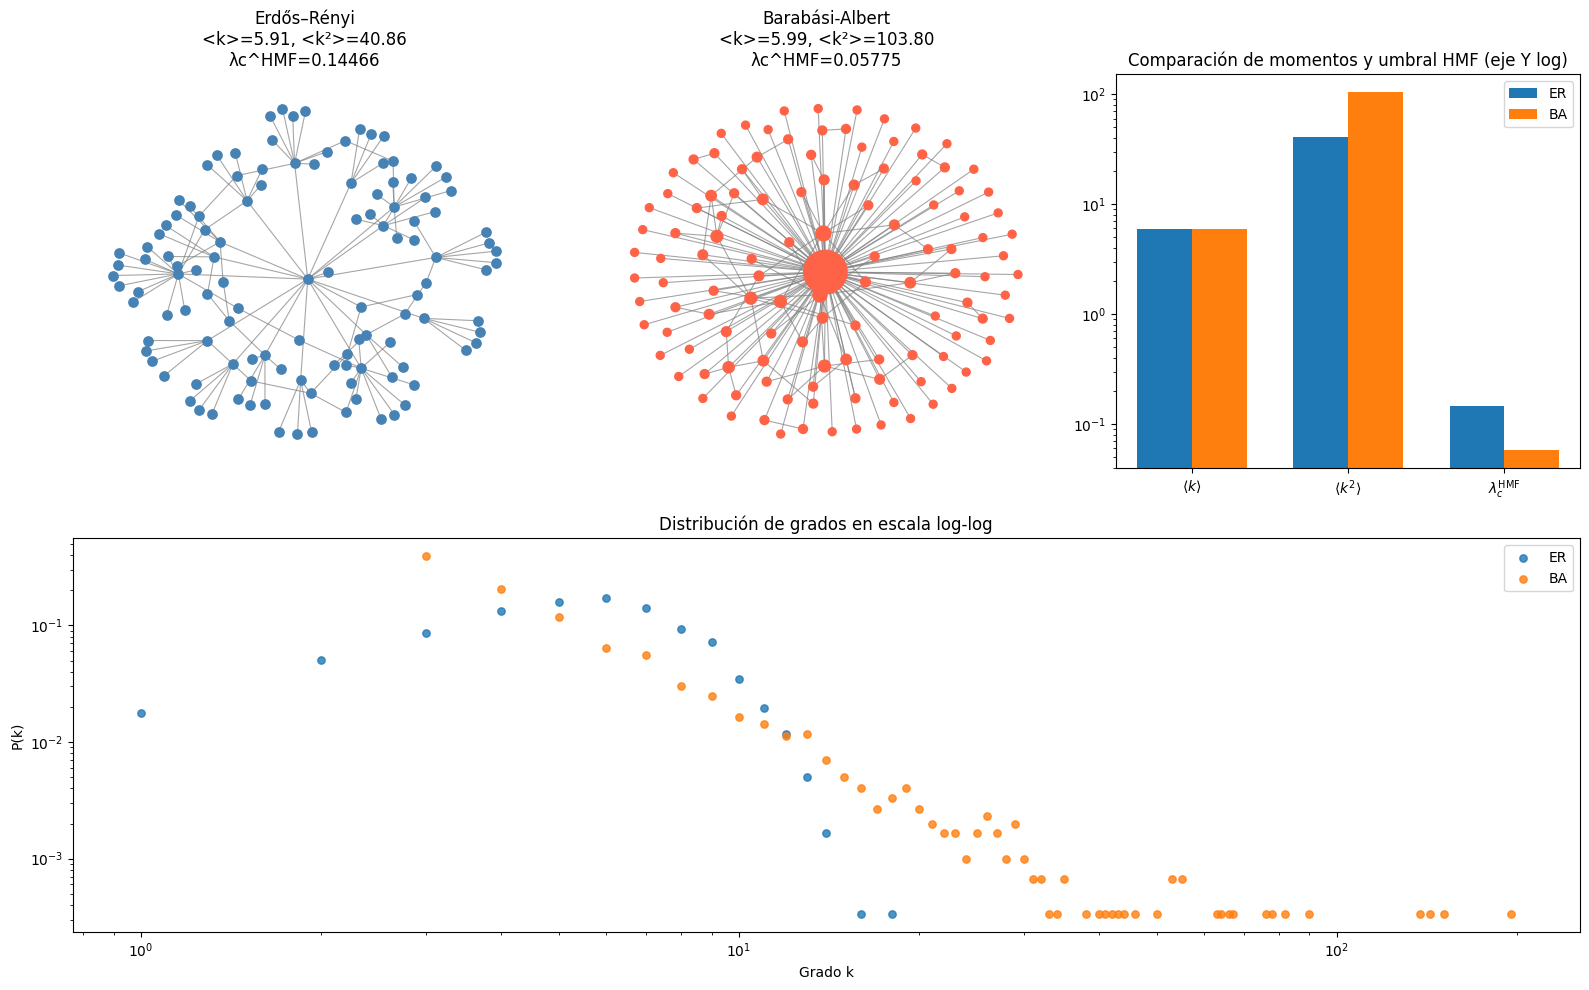

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

# =========================================================
# Ejemplo ilustrativo: ER vs BA
# mismo orden de <k>, distinta heterogeneidad
# -> cambia <k^2> y cambia lambda_c^HMF
# =========================================================

seed = 42
rng = np.random.default_rng(seed)

# -----------------------------
# 1. Construimos dos redes
# -----------------------------
n = 3000
target_mean_degree = 6   # más bajo que 10 para que la heterogeneidad destaque más

# Red homogénea aproximada: Erdős–Rényi
p = target_mean_degree / (n - 1)
G_er = nx.erdos_renyi_graph(n=n, p=p, seed=seed)

# Red heterogénea: Barabási–Albert
# En BA, <k> ≈ 2m
m_ba = target_mean_degree // 2   # si target_mean_degree=6 => m=3
G_ba = nx.barabasi_albert_graph(n=n, m=m_ba, seed=seed)

# -----------------------------
# 2. Funciones auxiliares
# -----------------------------
def degree_stats(G):
    degrees = np.array([d for _, d in G.degree()])
    k_mean = degrees.mean()
    k2_mean = np.mean(degrees**2)
    lambda_hmf = k_mean / k2_mean if k2_mean > 0 else np.nan
    return degrees, k_mean, k2_mean, lambda_hmf

def empirical_degree_distribution(degrees):
    vals, counts = np.unique(degrees, return_counts=True)
    pk = counts / counts.sum()
    return vals, pk

def bfs_induced_subgraph(G, start_node, max_nodes=120):
    """
    Construye un subgrafo inducido usando BFS desde un nodo dado.
    Así la muestra queda conectada y visualmente más informativa.
    """
    visited = set([start_node])
    queue = deque([start_node])
    order = [start_node]

    while queue and len(order) < max_nodes:
        u = queue.popleft()
        for v in G.neighbors(u):
            if v not in visited:
                visited.add(v)
                queue.append(v)
                order.append(v)
                if len(order) >= max_nodes:
                    break

    return G.subgraph(order).copy()

deg_er, kmean_er, k2_er, lam_er = degree_stats(G_er)
deg_ba, kmean_ba, k2_ba, lam_ba = degree_stats(G_ba)

# -----------------------------
# 3. Resultados
# -----------------------------
print("=== Red Erdős–Rényi (más homogénea) ===")
print(f"<k>     = {kmean_er:.3f}")
print(f"<k^2>   = {k2_er:.3f}")
print(f"lambda_c^HMF = <k>/<k^2> = {lam_er:.6f}")

print("\n=== Red Barabási–Albert (más heterogénea) ===")
print(f"<k>     = {kmean_ba:.3f}")
print(f"<k^2>   = {k2_ba:.3f}")
print(f"lambda_c^HMF = <k>/<k^2> = {lam_ba:.6f}")

print("\nRazón de umbrales ER / BA:")
print(f"{lam_er / lam_ba:.2f}x")

# -----------------------------
# 4. Subgrafos más legibles
# -----------------------------
# Elegimos un nodo de alto grado como semilla para que la muestra sea informativa
hub_er = max(G_er.degree, key=lambda x: x[1])[0]
hub_ba = max(G_ba.degree, key=lambda x: x[1])[0]

sample_er = bfs_induced_subgraph(G_er, hub_er, max_nodes=120)
sample_ba = bfs_induced_subgraph(G_ba, hub_ba, max_nodes=120)

# -----------------------------
# 5. Figura
# -----------------------------
fig = plt.figure(figsize=(16, 10))

ax1 = plt.subplot2grid((2, 3), (0, 0))
ax2 = plt.subplot2grid((2, 3), (0, 1))
ax3 = plt.subplot2grid((2, 3), (0, 2))
ax4 = plt.subplot2grid((2, 3), (1, 0), colspan=3)

# ---- Dibujo ER
pos_er = nx.spring_layout(sample_er, seed=seed, k=0.22)
nx.draw_networkx_edges(sample_er, pos_er, ax=ax1, edge_color="gray", width=0.8, alpha=0.7)
nx.draw_networkx_nodes(sample_er, pos_er, ax=ax1, node_size=45, node_color="steelblue")
ax1.set_title(
    f"Erdős–Rényi\n"
    f"<k>={kmean_er:.2f}, <k²>={k2_er:.2f}\n"
    f"λc^HMF={lam_er:.5f}"
)
ax1.axis("off")

# ---- Dibujo BA
# tamaño de nodo proporcional al grado local para que los hubs se noten
deg_sample_ba = dict(sample_ba.degree())
node_sizes_ba = [25 + 8 * deg_sample_ba[n] for n in sample_ba.nodes()]

pos_ba = nx.spring_layout(sample_ba, seed=seed, k=0.22)
nx.draw_networkx_edges(sample_ba, pos_ba, ax=ax2, edge_color="gray", width=0.8, alpha=0.7)
nx.draw_networkx_nodes(sample_ba, pos_ba, ax=ax2, node_size=node_sizes_ba, node_color="tomato")
ax2.set_title(
    f"Barabási-Albert\n"
    f"<k>={kmean_ba:.2f}, <k²>={k2_ba:.2f}\n"
    f"λc^HMF={lam_ba:.5f}"
)
ax2.axis("off")

# ---- Barras comparativas con eje log en Y
labels = [r"$\langle k \rangle$", r"$\langle k^2 \rangle$", r"$\lambda_c^{\mathrm{HMF}}$"]
vals_er = [kmean_er, k2_er, lam_er]
vals_ba = [kmean_ba, k2_ba, lam_ba]

x = np.arange(len(labels))
width = 0.35

ax3.bar(x - width/2, vals_er, width=width, label="ER")
ax3.bar(x + width/2, vals_ba, width=width, label="BA")
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.set_yscale("log")
ax3.set_title("Comparación de momentos y umbral HMF (eje Y log)")
ax3.legend()

# ---- Distribuciones de grado en log-log
k_er_vals, pk_er = empirical_degree_distribution(deg_er)
k_ba_vals, pk_ba = empirical_degree_distribution(deg_ba)

mask_er = k_er_vals > 0
mask_ba = k_ba_vals > 0

ax4.scatter(k_er_vals[mask_er], pk_er[mask_er], s=28, alpha=0.8, label="ER")
ax4.scatter(k_ba_vals[mask_ba], pk_ba[mask_ba], s=28, alpha=0.8, label="BA")
ax4.set_xscale("log")
ax4.set_yscale("log")
ax4.set_xlabel("Grado k")
ax4.set_ylabel("P(k)")
ax4.set_title("Distribución de grados en escala log-log")
ax4.legend()

plt.tight_layout()
plt.show()

> Aquí ambas redes tienen grado medio parecido, pero no la misma heterogeneidad. En BA aparecen hubs, eso hace crecer ($\langle k^2\rangle$), y como en HMF el umbral es ($\langle k\rangle/\langle k^2\rangle$), el umbral baja.



## 5. Aproximación espectral o QMF: el papel de $\lambda_1(A)$

Hasta ahora, con **HMF**, resumimos la red usando clases de grado: todos los nodos con el mismo $k$ se tratan como estadísticamente equivalentes. Esa aproximación captura bien el efecto de la heterogeneidad de grados, pero pierde información sobre **qué nodo está conectado con cuál**.

La aproximación **quenched mean field (QMF)** da un paso distinto. Aquí la red ya no se reemplaza por una descripción promediada por grados, sino que se trabaja directamente con la **matriz de adyacencia $A$ de una red fija**.

La palabra **quenched** quiere decir justamente eso: la red se considera **congelada** o **fija** durante la dinámica. Es decir, los enlaces no se están remezclando ni reemplazando por un entorno promedio; el proceso epidémico ocurre sobre una realización concreta del grafo. Por eso, en vez de describir la infección por clases de grado, se sigue la probabilidad de infección de cada nodo por separado.

En ese marco, una aproximación clásica para el modelo **SIS** lleva a la relación:

$$
\lambda_c^{\mathrm{QMF}} \approx \frac{1}{\lambda_1(A)},
$$

donde $\lambda_1(A)$ es el **mayor autovalor** de la matriz de adyacencia, también llamado **radio espectral**.

La idea detrás de esta expresión es la siguiente. Si linealizamos la dinámica cerca del estado libre de infección, la evolución inicial de la perturbación infecciosa queda gobernada por la matriz $A$. En esa linealización, el modo que más crece es el asociado al autovalor más grande, $\lambda_1(A)$. Por eso, cuanto mayor es $\lambda_1(A)$, mayor es la capacidad de la red para **amplificar** pequeñas infecciones, y menor es el umbral crítico predicho por esta aproximación.

### Intuición

El autovector principal de $A$ identifica la **dirección estructural dominante** de la red: los nodos y patrones de conectividad que contribuyen más fuertemente a la amplificación del proceso. Si la infección se concentra en esa estructura dominante, la red ofrece trayectorias especialmente eficientes para sostenerla o expandirla.

Dicho de manera más intuitiva:

* si $\lambda_1(A)$ es grande, la red amplifica bien la infección;
* si $\lambda_1(A)$ es más pequeño, la amplificación estructural es menor.

Por eso, en la aproximación QMF, el umbral escala como $1/\lambda_1(A)$.

### Comparación conceptual entre HMF y QMF

La diferencia entre ambos enfoques es importante:

* **HMF** reemplaza la red por información agregada de la distribución de grados;
* **QMF** conserva la red concreta y usa la estructura completa codificada en $A$.

Entonces:

* **HMF** enfatiza que la heterogeneidad de grados importa;
* **QMF** enfatiza que también importa **cómo están organizadas exactamente las conexiones**.

Ese punto es crucial, porque dos redes pueden tener distribuciones de grado parecidas y, sin embargo, tener radios espectrales distintos debido a su organización fina.

### Cuidado!!!

No conviene afirmar:

> “$1/\lambda_1(A)$ es el umbral exacto del SIS”.

Eso sería demasiado fuerte. Lo correcto es decir:

> “$1/\lambda_1(A)$ es una aproximación espectral clásica para el umbral del SIS y un indicador muy informativo de la capacidad de amplificación de la red”.

La literatura posterior mostró que **HMF** y **QMF** pueden diferir de manera importante, especialmente en redes heterogéneas, y que el comportamiento asintótico del SIS sobre redes fijas puede ser más sutil de lo que sugiere una sola fórmula.

> **la topología de la red desplaza el umbral epidémico, y el radio espectral resume una parte central de esa capacidad de amplificación**.

---

### En resumen

> Con HMF agrupábamos nodos por grado y describíamos la red de manera agregada. En cambio, en QMF la red se mantiene fija, o “quenched”: no se promedia, no se remezcla, sino que usamos directamente su matriz de adyacencia. Entonces la dinámica se analiza nodo a nodo sobre una red concreta. Al linealizar el SIS cerca del estado libre de infección, la cantidad clave pasa a ser el mayor autovalor de $A$, es decir, el radio espectral. La regla clásica es que el umbral se aproxima por $1/\lambda_1(A)$. La intuición es que $\lambda_1(A)$ mide qué tan bien la red puede amplificar una infección pequeña. Si ese valor es grande, la infección encuentra una estructura muy favorable para persistir, y el umbral baja.


### Qué dicen y qué no dicen estos umbrales proxy

Estas expresiones sirven para orientar la intuición, pero no deben leerse como si fueran un termómetro exacto en cualquier red finita.

- $\langle k \rangle / \langle k^2 \rangle$ resume heterogeneidad, pero ignora bastante de la geometría fina de la red.
- $1/\lambda_1(A)$ usa más estructura global, pero puede estar muy influido por hubs o por localización espectral.
- Ambas aproximaciones se usan sobre todo para procesos tipo `SIS`; no equivalen automáticamente a una predicción exacta del tamaño final en `SIR`.

La lectura correcta es: si dos redes tienen proxies muy distintos, es razonable esperar regímenes de difusión distintos; no es correcto prometer el valor exacto del umbral a partir de un solo proxy.


=== Erdős–Rényi ===
<k>              = 5.9113
<k^2>            = 40.8627
lambda_c^HMF     = 0.144663
lambda_1(A)      = 7.081256
lambda_c^QMF     = 0.141218

=== Barabási–Albert ===
<k>              = 5.9940
<k^2>            = 103.8000
lambda_c^HMF     = 0.057746
lambda_1(A)      = 17.530585
lambda_c^QMF     = 0.057043


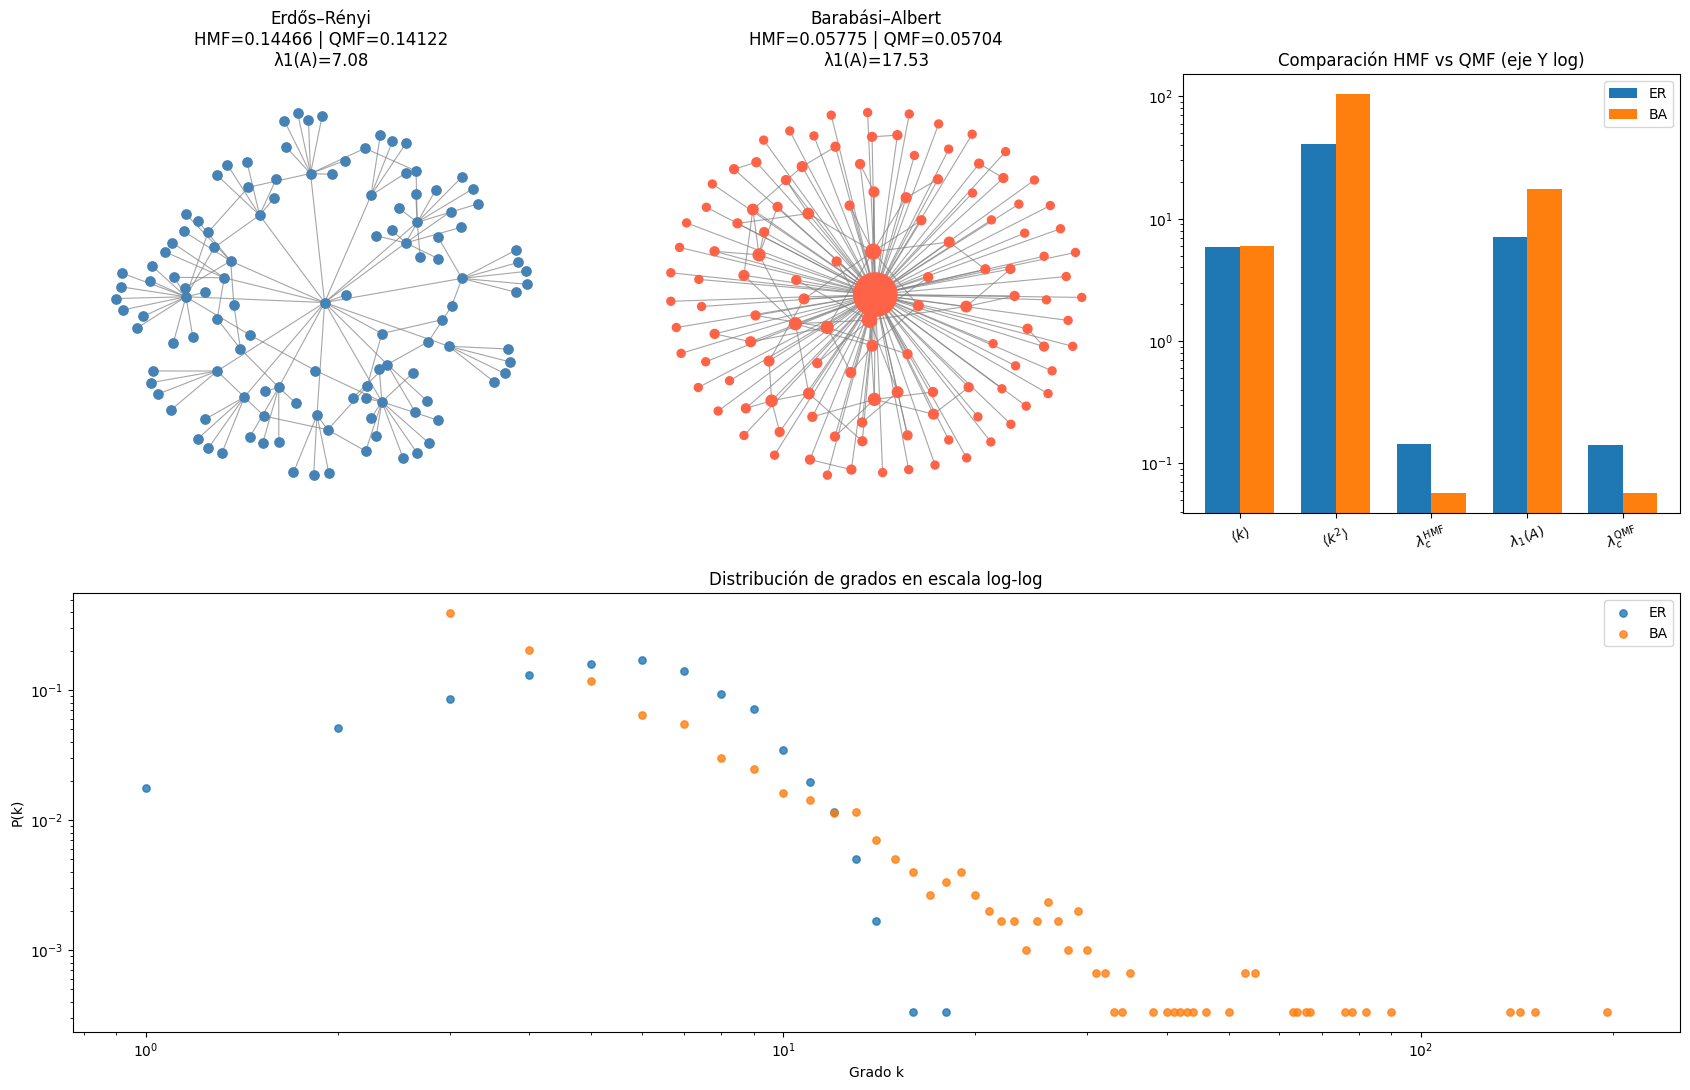

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

# =========================================================
# Ejemplo ilustrativo: comparar HMF vs QMF en ER y BA
# =========================================================

seed = 42
n = 3000
target_mean_degree = 6

# -----------------------------
# 1. Construimos dos redes
# -----------------------------
# ER: red más homogénea
p = target_mean_degree / (n - 1)
G_er = nx.erdos_renyi_graph(n=n, p=p, seed=seed)

# BA: red más heterogénea
m_ba = target_mean_degree // 2   # <k> ~ 2m
G_ba = nx.barabasi_albert_graph(n=n, m=m_ba, seed=seed)

# -----------------------------
# 2. Funciones auxiliares
# -----------------------------
def degree_stats(G):
    degrees = np.array([d for _, d in G.degree()])
    k_mean = degrees.mean()
    k2_mean = np.mean(degrees**2)
    lambda_hmf = k_mean / k2_mean if k2_mean > 0 else np.nan
    return degrees, k_mean, k2_mean, lambda_hmf

def lambda1_adjacency(G):
    """
    Mayor autovalor de A usando scipy sparse a través de networkx.
    """
    A = nx.to_scipy_sparse_array(G, format="csr", dtype=float)
    vals = nx.adjacency_spectrum(G)  # funciona bien para tamaño moderado
    lambda1 = np.max(np.real(vals))
    return float(lambda1)

def empirical_degree_distribution(degrees):
    vals, counts = np.unique(degrees, return_counts=True)
    pk = counts / counts.sum()
    return vals, pk

def bfs_induced_subgraph(G, start_node, max_nodes=120):
    visited = {start_node}
    queue = deque([start_node])
    order = [start_node]

    while queue and len(order) < max_nodes:
        u = queue.popleft()
        for v in G.neighbors(u):
            if v not in visited:
                visited.add(v)
                queue.append(v)
                order.append(v)
                if len(order) >= max_nodes:
                    break

    return G.subgraph(order).copy()

# -----------------------------
# 3. Cálculos
# -----------------------------
deg_er, kmean_er, k2_er, lam_hmf_er = degree_stats(G_er)
deg_ba, kmean_ba, k2_ba, lam_hmf_ba = degree_stats(G_ba)

lambda1_er = lambda1_adjacency(G_er)
lambda1_ba = lambda1_adjacency(G_ba)

lam_qmf_er = 1 / lambda1_er
lam_qmf_ba = 1 / lambda1_ba

# -----------------------------
# 4. Resultados numéricos
# -----------------------------
print("=== Erdős–Rényi ===")
print(f"<k>              = {kmean_er:.4f}")
print(f"<k^2>            = {k2_er:.4f}")
print(f"lambda_c^HMF     = {lam_hmf_er:.6f}")
print(f"lambda_1(A)      = {lambda1_er:.6f}")
print(f"lambda_c^QMF     = {lam_qmf_er:.6f}")

print("\n=== Barabási–Albert ===")
print(f"<k>              = {kmean_ba:.4f}")
print(f"<k^2>            = {k2_ba:.4f}")
print(f"lambda_c^HMF     = {lam_hmf_ba:.6f}")
print(f"lambda_1(A)      = {lambda1_ba:.6f}")
print(f"lambda_c^QMF     = {lam_qmf_ba:.6f}")

# -----------------------------
# 5. Subgrafos para visualización
# -----------------------------
hub_er = max(G_er.degree, key=lambda x: x[1])[0]
hub_ba = max(G_ba.degree, key=lambda x: x[1])[0]

sample_er = bfs_induced_subgraph(G_er, hub_er, max_nodes=120)
sample_ba = bfs_induced_subgraph(G_ba, hub_ba, max_nodes=120)

# -----------------------------
# 6. Figura
# -----------------------------
fig = plt.figure(figsize=(17, 11))

ax1 = plt.subplot2grid((2, 3), (0, 0))
ax2 = plt.subplot2grid((2, 3), (0, 1))
ax3 = plt.subplot2grid((2, 3), (0, 2))
ax4 = plt.subplot2grid((2, 3), (1, 0), colspan=3)

# --- Red ER
pos_er = nx.spring_layout(sample_er, seed=seed, k=0.22)
nx.draw_networkx_edges(sample_er, pos_er, ax=ax1, edge_color="gray", width=0.8, alpha=0.7)
nx.draw_networkx_nodes(sample_er, pos_er, ax=ax1, node_size=45, node_color="steelblue")
ax1.set_title(
    "Erdős-Rényi\n"
    f"HMF={lam_hmf_er:.5f} | QMF={lam_qmf_er:.5f}\n"
    f"λ1(A)={lambda1_er:.2f}"
)
ax1.axis("off")

# --- Red BA
deg_sample_ba = dict(sample_ba.degree())
node_sizes_ba = [25 + 8 * deg_sample_ba[n] for n in sample_ba.nodes()]
pos_ba = nx.spring_layout(sample_ba, seed=seed, k=0.22)
nx.draw_networkx_edges(sample_ba, pos_ba, ax=ax2, edge_color="gray", width=0.8, alpha=0.7)
nx.draw_networkx_nodes(sample_ba, pos_ba, ax=ax2, node_size=node_sizes_ba, node_color="tomato")
ax2.set_title(
    "Barabási-Albert\n"
    f"HMF={lam_hmf_ba:.5f} | QMF={lam_qmf_ba:.5f}\n"
    f"λ1(A)={lambda1_ba:.2f}"
)
ax2.axis("off")

# --- Barras comparativas en log scale
labels = [
    r"$\langle k \rangle$",
    r"$\langle k^2 \rangle$",
    r"$\lambda_c^{\mathrm{HMF}}$",
    r"$\lambda_1(A)$",
    r"$\lambda_c^{\mathrm{QMF}}$"
]
vals_er = [kmean_er, k2_er, lam_hmf_er, lambda1_er, lam_qmf_er]
vals_ba = [kmean_ba, k2_ba, lam_hmf_ba, lambda1_ba, lam_qmf_ba]

x = np.arange(len(labels))
width = 0.36

ax3.bar(x - width/2, vals_er, width=width, label="ER")
ax3.bar(x + width/2, vals_ba, width=width, label="BA")
ax3.set_xticks(x)
ax3.set_xticklabels(labels, rotation=20)
ax3.set_yscale("log")
ax3.set_title("Comparación HMF vs QMF (eje Y log)")
ax3.legend()

# --- Distribuciones de grado en log-log
k_er_vals, pk_er = empirical_degree_distribution(deg_er)
k_ba_vals, pk_ba = empirical_degree_distribution(deg_ba)

mask_er = k_er_vals > 0
mask_ba = k_ba_vals > 0

ax4.scatter(k_er_vals[mask_er], pk_er[mask_er], s=28, alpha=0.8, label="ER")
ax4.scatter(k_ba_vals[mask_ba], pk_ba[mask_ba], s=28, alpha=0.8, label="BA")
ax4.set_xscale("log")
ax4.set_yscale("log")
ax4.set_xlabel("Grado k")
ax4.set_ylabel("P(k)")
ax4.set_title("Distribución de grados en escala log-log")
ax4.legend()

plt.tight_layout()
plt.show()

## Qué muestra este ejemplo

> HMF y QMF no usan la misma información. HMF mira la distribución de grados a través de ($\langle k\rangle$) y ($\langle k^2\rangle$). QMF, en cambio, usa la red concreta a través del mayor autovalor de la matriz de adyacencia. En ambas redes, el umbral baja en BA, pero QMF y HMF no tienen por qué coincidir.

Aquí las dos redes tienen prácticamente el mismo grado medio. Por lo tanto, la diferencia no viene de que una esté simplemente más conectada. La diferencia aparece en la heterogeneidad: en Barabási-Albert el segundo momento $\langle k^2\rangle$ es mucho mayor por la presencia de hubs. Por eso el umbral HMF cae de aproximadamente 0.145 a 0.058. Y si miro la aproximación espectral, pasa algo consistente: el mayor autovalor de la matriz de adyacencia también aumenta mucho, lo que vuelve a empujar el umbral hacia abajo. En ambas lecturas, la conclusión es la misma: la heterogeneidad estructural facilita la persistencia del contagio.


> En HMF el umbral depende de cuán heterogénea es la distribución de grados. En QMF, además, importa la geometría completa de la red. Eso se resume en ($\lambda_1(A)$): si el mayor autovalor es grande, la red amplifica mejor la infección y el umbral baja.



=== BA original ===
<k>          = 3.9980
<k^2>        = 51.7305
lambda_c^HMF = 0.077285
lambda_1(A)  = 14.904396
lambda_c^QMF = 0.067094

=== Mismo degree sequence, rewired ===
<k>          = 3.9980
<k^2>        = 51.7305
lambda_c^HMF = 0.077285
lambda_1(A)  = 15.471334
lambda_c^QMF = 0.064636

Chequeo:
¿Secuencia de grados igual?: True

Cambio porcentual en QMF: -3.66%
Cambio porcentual en λ1(A): 3.80%


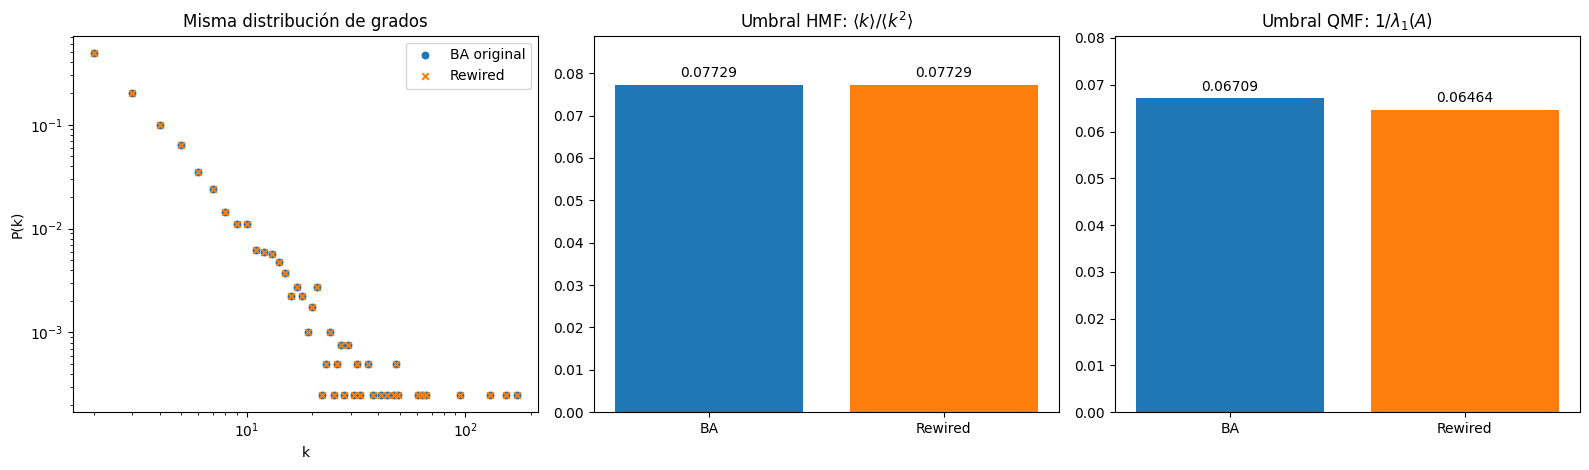

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.sparse.linalg import eigsh

# =========================================================
# MISMA secuencia de grados, distinto wiring
# -> HMF exactamente igual
# -> QMF cambia
#
# Para aumentar un poco el efecto:
# 1) usamos una BA más heterogénea (m=2)
# 2) hacemos rewiring degree-preserving más intenso
# 3) generamos varias redes rewired y elegimos la que más cambie QMF
# =========================================================

seed = 42
rng = np.random.default_rng(seed)

n = 4000
m = 2   # BA más heterogénea que m=3

# -----------------------------
# 1. Red base BA
# -----------------------------
G_ba = nx.barabasi_albert_graph(n=n, m=m, seed=seed)

# -----------------------------
# 2. Funciones auxiliares
# -----------------------------
def degree_stats(G):
    degrees = np.array([d for _, d in G.degree()])
    k_mean = degrees.mean()
    k2_mean = np.mean(degrees**2)
    lambda_hmf = k_mean / k2_mean
    return degrees, k_mean, k2_mean, lambda_hmf

def lambda1_adjacency(G):
    A = nx.to_scipy_sparse_array(G, format="csr", dtype=float)
    val = eigsh(A, k=1, which="LA", return_eigenvectors=False)[0]
    return float(val)

def empirical_degree_distribution(degrees):
    vals, counts = np.unique(degrees, return_counts=True)
    pk = counts / counts.sum()
    return vals, pk

def degree_preserving_rewire(G, nswap, max_tries, seed):
    H = G.copy()
    nx.double_edge_swap(H, nswap=nswap, max_tries=max_tries, seed=seed)
    return H

# -----------------------------
# 3. Red base: métricas
# -----------------------------
deg_ba, k_ba, k2_ba, lam_hmf_ba = degree_stats(G_ba)
lambda1_ba = lambda1_adjacency(G_ba)
lam_qmf_ba = 1 / lambda1_ba

# -----------------------------
# 4. Generamos varias rewired y elegimos la que más cambie QMF
# -----------------------------
n_candidates = 8
nswap = 250000
max_tries = 2500000

best_graph = None
best_metrics = None
best_delta = -np.inf

for i in range(n_candidates):  # generamos varias redes rewired y elegimos una con cambio máximo en QMF para ejemplo
    H = degree_preserving_rewire(
        G_ba,
        nswap=nswap,
        max_tries=max_tries,
        seed=seed + i + 1
    )

    deg_h, k_h, k2_h, lam_hmf_h = degree_stats(H)
    lambda1_h = lambda1_adjacency(H)
    lam_qmf_h = 1 / lambda1_h

    delta = abs(lam_qmf_h - lam_qmf_ba) / lam_qmf_ba  # cambio porcentual en QMF

    if delta > best_delta:
        best_delta = delta
        best_graph = H
        best_metrics = (deg_h, k_h, k2_h, lam_hmf_h, lambda1_h, lam_qmf_h)

G_rw = best_graph
deg_rw, k_rw, k2_rw, lam_hmf_rw, lambda1_rw, lam_qmf_rw = best_metrics

# -----------------------------
# 5. Resultados
# -----------------------------
print("=== BA original ===")
print(f"<k>          = {k_ba:.4f}")
print(f"<k^2>        = {k2_ba:.4f}")
print(f"lambda_c^HMF = {lam_hmf_ba:.6f}")
print(f"lambda_1(A)  = {lambda1_ba:.6f}")
print(f"lambda_c^QMF = {lam_qmf_ba:.6f}")

print("\n=== Mismo degree sequence, rewired ===")
print(f"<k>          = {k_rw:.4f}")
print(f"<k^2>        = {k2_rw:.4f}")
print(f"lambda_c^HMF = {lam_hmf_rw:.6f}")
print(f"lambda_1(A)  = {lambda1_rw:.6f}")
print(f"lambda_c^QMF = {lam_qmf_rw:.6f}")

print("\nChequeo:")
print("¿Secuencia de grados igual?:", np.array_equal(np.sort(deg_ba), np.sort(deg_rw)))

delta_qmf_pct = 100 * (lam_qmf_rw - lam_qmf_ba) / lam_qmf_ba
delta_lambda1_pct = 100 * (lambda1_rw - lambda1_ba) / lambda1_ba

print(f"\nCambio porcentual en QMF: {delta_qmf_pct:.2f}%")
print(f"Cambio porcentual en λ1(A): {delta_lambda1_pct:.2f}%")

# -----------------------------
# 6. Figura
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Panel 1: distribución de grados
kvals_ba, pk_ba = empirical_degree_distribution(deg_ba)
kvals_rw, pk_rw = empirical_degree_distribution(deg_rw)

axes[0].scatter(kvals_ba, pk_ba, s=22, label="BA original")
axes[0].scatter(kvals_rw, pk_rw, s=22, label="Rewired", marker="x")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("k")
axes[0].set_ylabel("P(k)")
axes[0].set_title("Misma distribución de grados")
axes[0].legend()

# Panel 2: HMF
labels = ["BA", "Rewired"]
x = np.arange(2)

axes[1].bar(x, [lam_hmf_ba, lam_hmf_rw], color=["tab:blue", "tab:orange"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title(r"Umbral HMF: $\langle k \rangle / \langle k^2 \rangle$")
axes[1].set_ylim(0, max(lam_hmf_ba, lam_hmf_rw) * 1.15)

for xi, yi in zip(x, [lam_hmf_ba, lam_hmf_rw]):
    axes[1].text(xi, yi + 0.001, f"{yi:.5f}", ha="center", va="bottom", fontsize=10)

# Panel 3: umbral QMF de ambos modelos
axes[2].bar(x, [lam_qmf_ba, lam_qmf_rw], color=["tab:blue", "tab:orange"])
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_title(r"Umbral QMF: $1/\lambda_1(A)$")
axes[2].set_ylim(0, max(lam_qmf_ba, lam_qmf_rw) * 1.20)

for xi, yi in zip(x, [lam_qmf_ba, lam_qmf_rw]):
    axes[2].text(xi, yi + 0.001, f"{yi:.5f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

Como la secuencia de grados es la misma, HMF no cambia. Pero al reordenar enlaces cambia el mayor autovalor y por tanto cambia QMF. Eso muestra que QMF ve geometría fina de la red que HMF no ve.

## 6. Otro ejemplo: medir heterogeneidad y radio espectral

El siguiente bloque construye tres redes con tamaño comparable:

- Erdős–Rényi (ER),
- Watts–Strogatz (WS),
- Barabási–Albert (BA),

y compara dos cantidades relevantes para difusión:

1. $ \langle k \rangle / \langle k^2 \rangle $ (intuición HMF),
2. $ 1/\lambda_1(A) $ (intuición espectral).

ER:
  n: 300
  m: 1350
  k_mean: 9.0000
  k2_mean: 89.4133
  hmf_proxy: 0.1007
  spectral_proxy: 0.0998
  lambda1: 10.0169

WS:
  n: 300
  m: 1200
  k_mean: 8.0000
  k2_mean: 64.6467
  hmf_proxy: 0.1237
  spectral_proxy: 0.1227
  lambda1: 8.1482

BA:
  n: 300
  m: 1184
  k_mean: 7.8933
  k2_mean: 110.5800
  hmf_proxy: 0.0714
  spectral_proxy: 0.0736
  lambda1: 13.5861



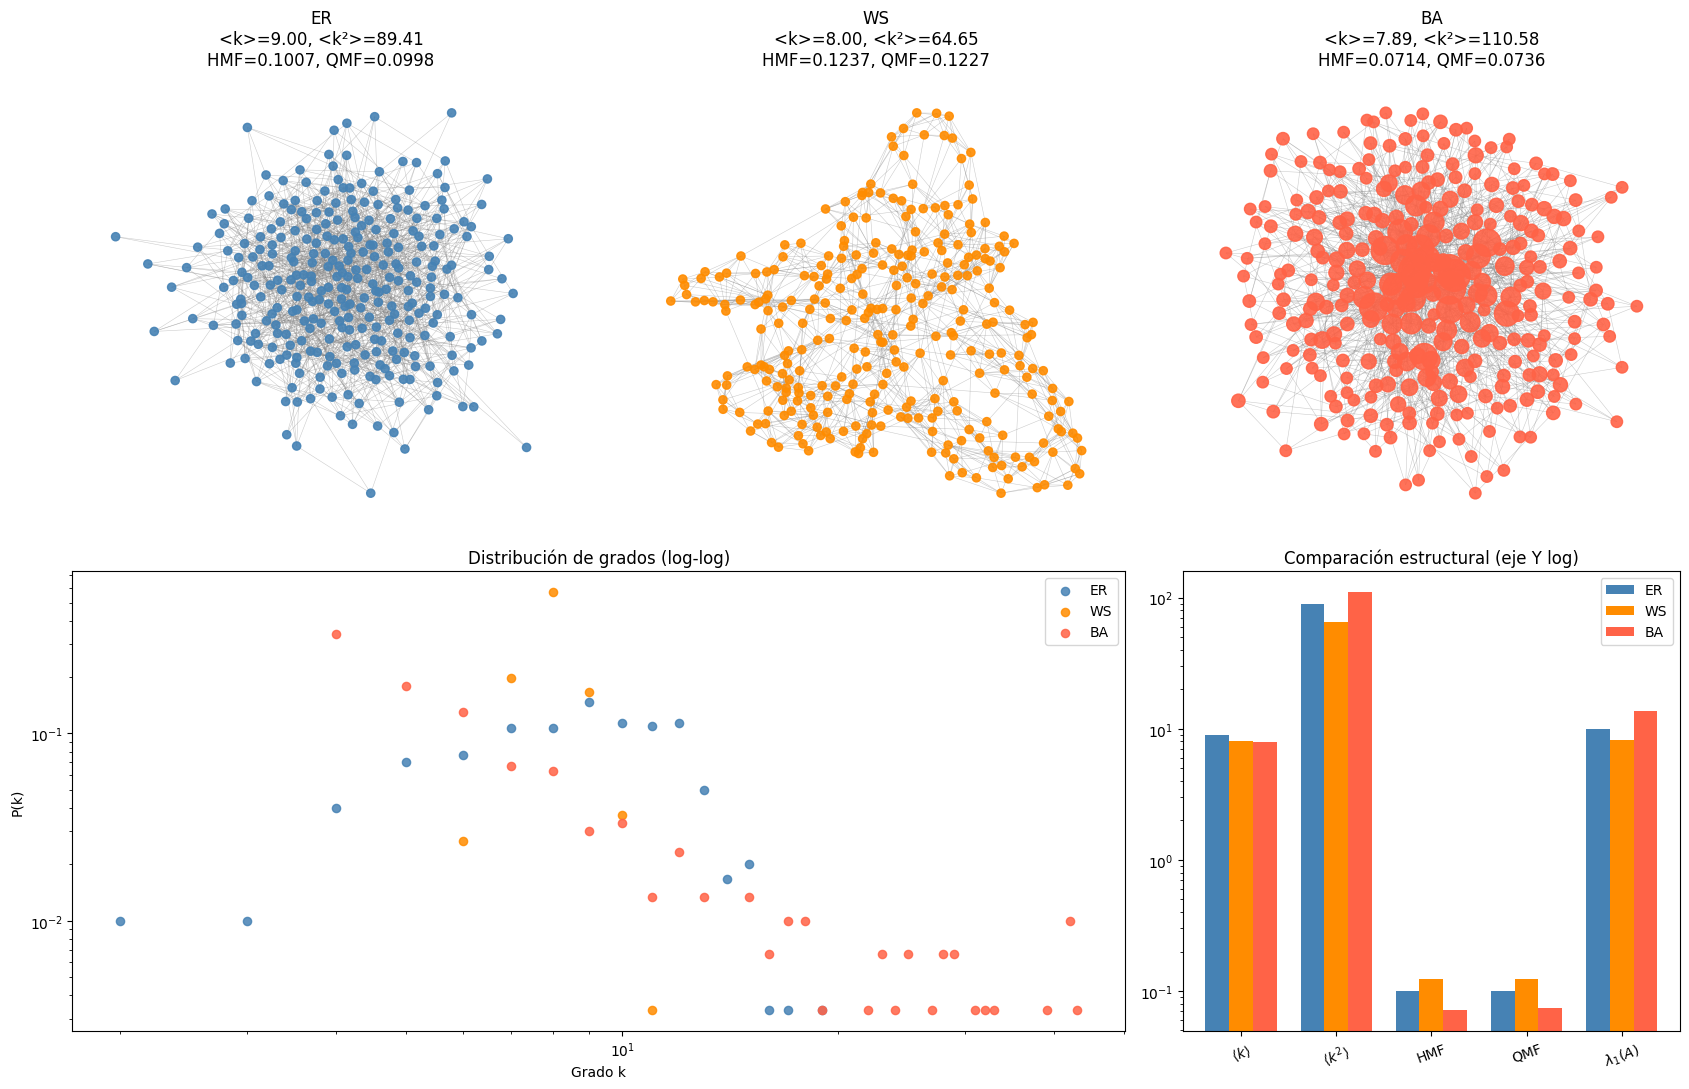

In [22]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(7)

# -----------------------------
# 1. Construcción de redes
# -----------------------------
n = 300
G_er = nx.erdos_renyi_graph(n, 0.03, seed=7)
G_ws = nx.watts_strogatz_graph(n, k=8, p=0.08, seed=7)
G_ba = nx.barabasi_albert_graph(n, m=4, seed=7)

# -----------------------------
# 2. Métricas
# -----------------------------
def structural_threshold_proxies(G):
    degrees = np.array([d for _, d in G.degree()], dtype=float)
    k1 = degrees.mean()
    k2 = np.mean(degrees**2)
    A = nx.to_numpy_array(G, dtype=float)
    lambda1 = max(np.linalg.eigvalsh(A))
    return {
        "n": G.number_of_nodes(),
        "m": G.number_of_edges(),
        "degrees": degrees,
        "k_mean": k1,
        "k2_mean": k2,
        "hmf_proxy": k1 / k2 if k2 > 0 else np.nan,
        "spectral_proxy": 1 / lambda1 if lambda1 > 0 else np.nan,
        "lambda1": lambda1
    }

results = {
    "ER": structural_threshold_proxies(G_er),
    "WS": structural_threshold_proxies(G_ws),
    "BA": structural_threshold_proxies(G_ba),
}

# -----------------------------
# 3. Impresión ordenada
# -----------------------------
for name in ["ER", "WS", "BA"]:
    out = results[name]
    print(f"{name}:")
    for k, v in out.items():
        if k == "degrees":
            continue
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
    print()

# -----------------------------
# 4. Figura
# -----------------------------
fig = plt.figure(figsize=(17, 11))

# Layout:
# fila 1: 3 redes
# fila 2 col1-2: distribuciones
# fila 2 col3: barras comparativas
ax1 = plt.subplot2grid((2, 3), (0, 0))
ax2 = plt.subplot2grid((2, 3), (0, 1))
ax3 = plt.subplot2grid((2, 3), (0, 2))
ax4 = plt.subplot2grid((2, 3), (1, 0), colspan=2)
ax5 = plt.subplot2grid((2, 3), (1, 2))

# -----------------------------
# 5. Dibujos de redes
# -----------------------------
network_specs = [
    ("ER", G_er, ax1, "steelblue"),
    ("WS", G_ws, ax2, "darkorange"),
    ("BA", G_ba, ax3, "tomato"),
]

for name, G, ax, color in network_specs:
    deg = dict(G.degree())
    pos = nx.spring_layout(G, seed=7)

    if name == "BA":
        node_sizes = [20 + 12 * deg[v] for v in G.nodes()]
    else:
        node_sizes = [35 for _ in G.nodes()]

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="gray", width=0.4, alpha=0.4)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=color, alpha=0.9)

    ax.set_title(
        f"{name}\n"
        f"<k>={results[name]['k_mean']:.2f}, "
        f"<k²>={results[name]['k2_mean']:.2f}\n"
        f"HMF={results[name]['hmf_proxy']:.4f}, "
        f"QMF={results[name]['spectral_proxy']:.4f}"
    )
    ax.axis("off")

# -----------------------------
# 6. Distribuciones de grado
# -----------------------------
for name, color in [("ER", "steelblue"), ("WS", "darkorange"), ("BA", "tomato")]:
    deg = results[name]["degrees"]
    vals, counts = np.unique(deg, return_counts=True)
    pk = counts / counts.sum()
    ax4.scatter(vals, pk, s=35, alpha=0.85, label=name, color=color)

ax4.set_xscale("log")
ax4.set_yscale("log")
ax4.set_xlabel("Grado k")
ax4.set_ylabel("P(k)")
ax4.set_title("Distribución de grados (log-log)")
ax4.legend()

# -----------------------------
# 7. Barras comparativas
# -----------------------------
metrics = ["k_mean", "k2_mean", "hmf_proxy", "spectral_proxy", "lambda1"]
metric_labels = [r"$\langle k \rangle$", r"$\langle k^2 \rangle$", "HMF", "QMF", r"$\lambda_1(A)$"]

x = np.arange(len(metrics))
width = 0.25

vals_er = [results["ER"][m] for m in metrics]
vals_ws = [results["WS"][m] for m in metrics]
vals_ba = [results["BA"][m] for m in metrics]

ax5.bar(x - width, vals_er, width=width, label="ER", color="steelblue")
ax5.bar(x,         vals_ws, width=width, label="WS", color="darkorange")
ax5.bar(x + width, vals_ba, width=width, label="BA", color="tomato")

ax5.set_xticks(x)
ax5.set_xticklabels(metric_labels, rotation=20)
ax5.set_yscale("log")
ax5.set_title("Comparación estructural (eje Y log)")
ax5.legend()

plt.tight_layout()
plt.show()

> **ER** y **WS** son más homogéneas; **BA** es más heterogénea y muestra una cola de grados más pesada.
> Esa heterogeneidad eleva ( $\langle k^2 \rangle$ ) y también ( $\lambda_1(A)$ ).
> Por eso, tanto el proxy **HMF** como el **espectral/QMF** predicen un umbral más bajo en BA: la infección persiste más fácilmente en redes con hubs.

### Usualmente veremos algo como esto:

- ER: umbrales proxy relativamente moderados;
- WS: puede parecerse a ER en grado medio, pero con clustering y caminos distintos;
- BA: radio espectral mayor y $ \langle k^2 \rangle $ mucho más grande, lo que sugiere **menor umbral efectivo**.

La idea no es memorizar números exactos, sino entender la relación:

> **más heterogeneidad y/o mayor amplificación espectral $\Rightarrow$ más fácil sostener contagio**.

## 7. SIR y percolación: la idea clásica de Newman (2002)

Para el modelo **SIR**, Newman mostró una conexión muy poderosa con un problema de redes llamado **bond percolation**. La intuición es: en `SIR`, cada persona infectada tiene solo un tiempo limitado para transmitir la enfermedad y luego sale del proceso. Por eso, para estudiar el **tamaño final del brote**, muchas veces no necesitamos seguir toda la historia temporal paso a paso, basta con preguntar **por qué enlaces logró pasar realmente la infección**. 

### ¿Qué es percolación, en este contexto?

Aquí **percolación por enlaces** significa: tomamos la red de contactos y declaramos que cada enlace puede estar en uno de dos estados:

* **abierto**: la infección sí logra cruzarlo;
* **cerrado**: la infección no logra cruzarlo.

Si cada enlace está abierto con probabilidad $T$, entonces la pregunta pasa a ser geométrica:
**¿qué conjunto de nodos queda conectado por enlaces abiertos?**

Ese conjunto conectado se llama un **cluster** o **componente conectado** de enlaces abiertos. En lenguaje epidemiológico, ese cluster representa el conjunto de personas que podrían quedar alcanzadas por la infección. Newman muestra que, bajo las hipótesis de su modelo, el tamaño final del brote coincide precisamente con el tamaño del cluster alcanzable desde el caso inicial a través de enlaces abiertos. En ese sentido, el problema epidémico se vuelve equivalente a un problema de percolación.

### Transmisibilidad

La cantidad central en esta equivalencia es la **transmissibility**, que denotamos por $T$.
No es una tasa instantánea, sino una **probabilidad total de transmisión a lo largo de un enlace durante todo el período infeccioso**.

En el artículo, si $r_{ij}$ es la tasa de contacto infeccioso entre $i$ y $j$, y $t_i$ es el tiempo durante el cual $i$ permanece infeccioso, entonces la probabilidad de que $i$ efectivamente infecte a $j$ es

$$
T_{ij} = 1 - e^{-r_{ij} t_i}.
$$

> $T_{ij}$ es la probabilidad de que (i) logre infectar a (j) antes de recuperarse. El término exponencial representa la probabilidad de que no pase ningún evento de transmisión en todo ese tiempo; al restarlo de uno obtenemos la probabilidad de que sí haya transmisión.


Bajo hipótesis apropiadas de independencia e idéntica distribución (iid), el sistema se comporta como si todos los enlaces tuvieran una transmisibilidad promedio

$$
T = \langle T_{ij} \rangle.
$$

Y ese es justamente el parámetro que pasa a jugar el rol de "probabilidad de enlace abierto" en la percolación. Newman subraya además que, en ese marco, las propiedades estadísticas del brote dependen de $T$ y no de los detalles separados de tasas y tiempos.

### Qué gana uno con esta equivalencia

La equivalencia es importante porque cambia la pregunta dinámica

> “¿cómo evoluciona la infección en el tiempo?”

por una pregunta estructural

> “¿qué tan grande es el conjunto conectable mediante enlaces que realmente transmiten?”

Eso permite estudiar:

* el **tamaño típico de brotes**;
* cuándo puede aparecer un **brote macroscópico**;
* el **tamaño final** de una epidemia, si ocurre.

### Entocnes

Aquí aparece una diferencia importante entre `SIS` y `SIR`:

* en **SIS**, la pregunta central suele ser la **persistencia** de la infección y el umbral dinámico
* en **SIR**, una pregunta muy natural es el **tamaño final del brote**, porque cada nodo se infecta a lo más una vez y luego sale del proceso.

Por eso la conexión con percolación es especialmente natural en `SIR`: el foco deja de estar en la persistencia indefinida y pasa al **alcance final del brote**.

### Qué significa "exacta" aquí

Conviene ser muy preciso. En el marco tratado por Newman, la equivalencia es **exacta** para una amplia clase de modelos `SIR` sobre **redes estáticas aleatorias**, cuando el proceso puede resumirse por una transmissibility por enlace. En ese caso, la ocurrencia de epidemias y el tamaño final del brote pueden estudiarse exactamente con herramientas de percolación sobre la red.

Pero no conviene extrapolar esa afirmación sin cuidado. En redes empíricas con:

* **clustering** fuerte,
* **pesos**,
* **direccionalidad**,
* **memoria**,
* o **variación temporal**,

la intuición de percolación sigue siendo muy útil, pero ya no debe presentarse automáticamente como una equivalencia exacta sin adaptaciones adicionales.

### Intuición

Una forma simple de verlo es:

> En `SIR`, no todos los contactos potenciales terminan transmitiendo la enfermedad. Si marcamos solo los enlaces por donde la transmisión sí ocurre, el brote final coincide con el componente conectado que contiene al caso inicial. Por eso, estudiar `SIR` puede convertirse en estudiar conectividad aleatoria en una red.

## 8. Simulación simple de SIR sobre una red

Ahora implementamos una versión discreta y mínima de SIR sobre una red.


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import gridspec
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
import random

# =========================================================
# Simulación SIR discreta sobre redes
# Estados:
# 0 = S (susceptible)
# 1 = I (infectado)
# 2 = R (removido/recuperado)
# =========================================================

def make_graph(graph_type="BA", n=80, mean_degree=4, rewiring_p=0.1, seed=7):
    rng = np.random.default_rng(seed)
    
    if graph_type == "ER":
        p = mean_degree / max(n - 1, 1)
        G = nx.erdos_renyi_graph(n, p, seed=seed)
        
    elif graph_type == "WS":
        k = max(2, int(round(mean_degree)))
        if k % 2 == 1:
            k += 1
        k = min(k, n - 1 if (n - 1) % 2 == 0 else n - 2)
        G = nx.watts_strogatz_graph(n, k, rewiring_p, seed=seed)
        
    elif graph_type == "BA":
        m = max(1, int(round(mean_degree / 2)))
        m = min(m, n - 1)
        G = nx.barabasi_albert_graph(n, m, seed=seed)
        
    else:
        raise ValueError("graph_type debe ser 'ER', 'WS' o 'BA'")
    
    # Si la red no está conectada, usar componente gigante para visualización más clara
    if not nx.is_connected(G):
        giant = max(nx.connected_components(G), key=len)
        G = G.subgraph(giant).copy()
    
    return G

def simulate_sir(G, beta=0.2, mu=0.1, initial_infected_frac=0.05, T=30, seed=7):
    random.seed(seed)
    np.random.seed(seed)
    
    nodes = list(G.nodes())
    n = len(nodes)
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    
    states = np.zeros(n, dtype=int)  # todos susceptibles al inicio
    
    n_init = max(1, int(round(initial_infected_frac * n)))
    init_infected_nodes = random.sample(nodes, n_init)
    for node in init_infected_nodes:
        states[node_to_idx[node]] = 1
    
    history = [states.copy()]
    S_hist = [np.sum(states == 0)]
    I_hist = [np.sum(states == 1)]
    R_hist = [np.sum(states == 2)]
    
    for _ in range(T):
        new_states = states.copy()
        
        infected_nodes = [nodes[i] for i in range(n) if states[i] == 1]
        
        # contagio
        for u in infected_nodes:
            u_idx = node_to_idx[u]
            for v in G.neighbors(u):
                v_idx = node_to_idx[v]
                if states[v_idx] == 0:
                    if random.random() < beta:
                        new_states[v_idx] = 1
        
        # recuperación
        for u in infected_nodes:
            u_idx = node_to_idx[u]
            if random.random() < mu:
                new_states[u_idx] = 2
        
        states = new_states
        history.append(states.copy())
        S_hist.append(np.sum(states == 0))
        I_hist.append(np.sum(states == 1))
        R_hist.append(np.sum(states == 2))
    
    return history, np.array(S_hist), np.array(I_hist), np.array(R_hist), nodes

def plot_sir_snapshot(
    graph_type="BA",
    n=80,
    mean_degree=4,
    rewiring_p=0.1,
    beta=0.2,
    mu=0.1,
    initial_infected_frac=0.05,
    T=30,
    t_show=0,
    seed=7
):
    G = make_graph(
        graph_type=graph_type,
        n=n,
        mean_degree=mean_degree,
        rewiring_p=rewiring_p,
        seed=seed
    )
    
    history, S_hist, I_hist, R_hist, nodes = simulate_sir(
        G,
        beta=beta,
        mu=mu,
        initial_infected_frac=initial_infected_frac,
        T=T,
        seed=seed
    )
    
    t_show = min(t_show, len(history) - 1)
    state = history[t_show]
    
    color_map = []
    for s in state:
        if s == 0:
            color_map.append("tab:blue")   # S
        elif s == 1:
            color_map.append("tab:red")    # I
        else:
            color_map.append("tab:green")  # R
    
    fig = plt.figure(figsize=(13, 5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
    
    # --- red
    ax0 = plt.subplot(gs[0])
    pos = nx.spring_layout(G, seed=seed)
    nx.draw_networkx_edges(G, pos, ax=ax0, alpha=0.25, width=0.8, edge_color="gray")
    nx.draw_networkx_nodes(G, pos, ax=ax0, node_color=color_map, node_size=90)
    ax0.set_title(
        f"{graph_type} | t={t_show}\n"
        f"S={S_hist[t_show]}, I={I_hist[t_show]}, R={R_hist[t_show]}"
    )
    ax0.axis("off")
    
    # --- series temporales
    ax1 = plt.subplot(gs[1])
    tt = np.arange(len(S_hist))
    ax1.plot(tt, S_hist, label="S", linewidth=2)
    ax1.plot(tt, I_hist, label="I", linewidth=2)
    ax1.plot(tt, R_hist, label="R", linewidth=2)
    ax1.axvline(t_show, linestyle="--", linewidth=1.5, color="black", alpha=0.7)
    ax1.set_xlabel("Tiempo")
    ax1.set_ylabel("Número de nodos")
    ax1.set_title(f"SIR | beta={beta:.2f}, mu={mu:.2f}")
    ax1.legend()
    ax1.grid(alpha=0.25)
    
    plt.tight_layout()
    plt.show()

interact(
    plot_sir_snapshot,
    graph_type=Dropdown(options=["ER", "WS", "BA"], value="BA", description="Red"),
    n=IntSlider(min=40, max=150, step=10, value=80, description="n"),
    mean_degree=IntSlider(min=2, max=10, step=1, value=4, description="<k>"),
    rewiring_p=FloatSlider(min=0.0, max=0.5, step=0.05, value=0.10, description="p_WS"),
    beta=FloatSlider(min=0.01, max=0.80, step=0.01, value=0.20, description="beta"),
    mu=FloatSlider(min=0.01, max=0.80, step=0.01, value=0.10, description="mu"),
    initial_infected_frac=FloatSlider(min=0.01, max=0.20, step=0.01, value=0.05, description="I0 frac"),
    T=IntSlider(min=5, max=60, step=1, value=30, description="T"),
    t_show=IntSlider(min=0, max=60, step=1, value=0, description="t"),
    seed=IntSlider(min=1, max=50, step=1, value=7, description="seed")
);

interactive(children=(Dropdown(description='Red', index=2, options=('ER', 'WS', 'BA'), value='BA'), IntSlider(…

**Parámetros de la simulación.**
`beta` es la probabilidad de que un nodo infectado contagie a un vecino susceptible en un paso de tiempo.
`mu` es la probabilidad de que un nodo infectado se recupere y pase al estado `R` en ese paso.
`I0 frac` es la fracción inicial de nodos infectados.
`T` es la cantidad total de pasos simulados y `t` es el instante que se está visualizando en la red.
En `ER`, `WS` y `BA`, `n` es el número de nodos y `<k>` controla aproximadamente el grado medio; en `WS`, además, `p_WS` es la probabilidad de rewiring, que introduce atajos aleatorios.


#### Pueden probar:

- Mismo beta y mu, cambiar ER -> WS -> BA para ver cómo la topología cambia el brote.
- Subir beta y dejar fija la red para ver la transición entre brote pequeño y grande.
- Subir mu para mostrar cómo la recuperación corta la propagación.


### Qué mirar en la trayectoria

- Si $I(t)$ apenas despega y cae rápido: estamos en régimen subcrítico o cerca de él.
- Si $I(t)$ crece y luego cae mientras $R(t)$ termina grande: hubo brote macroscópico.
- En SIR, el interés muchas veces está en el **tamaño final**.
- En SIS, el interés suele estar en la **persistencia estacionaria**.

### Si cambias el criterio de desempeño, cambias la noción de importancia

No es lo mismo optimizar:

- **tamaño final** del brote;
- **peak** de infectados;
- **duración** de la difusión;
- **persistencia** de un estado endémico.

Un nodo que ayuda mucho a reducir el tamaño final no necesariamente es el mejor para retrasar el peak, y un nodo central para persistencia `SIS` no tiene por qué ser el más decisivo en un brote `SIR` corto. Por eso, antes de elegir una centralidad o una intervención, primero se fija el objetivo.


## 9. Importancia depende del proceso

Esta es la idea conceptual más importante de hoy!

### Caso 1: difusión tipo contagio simple

Si el mecanismo es "un vecino infectado ya puede transmitir", medidas locales como:

- grado,
- fuerza,
- accesibilidad local,

pueden ser muy informativas.

### Caso 2: persistencia en regiones densas

Si interesa mantener o sostener la difusión, entonces puede importar mucho estar embebido en una región estructuralmente robusta. Ahí aparece el valor de:

- $k$-core / coreness,
- densidad local,
- redundancia de caminos.

### Caso 3: flujo por caminos geodésicos

Si el proceso usa rutas tipo shortest paths, entonces **betweenness** puede ser relevante.

Pero ojo: una epidemia o difusión SIR/SIS **no necesita seguir caminos geodésicos**.  
Se propaga por contactos locales paralelos. Por eso betweenness muchas veces no es la mejor medida para contagio.

### Regla de oro

> **No existe una centralidad universalmente correcta.**  
> La medida adecuada depende del mecanismo de propagación, del horizonte temporal y del objetivo de intervención.

## 10. Intervención: random vs degree vs $k$-core

Una forma operativa de evaluar importancia es preguntar:

> Si remuevo o inmunizo ciertos nodos, ¿cuánto se reduce el brote?

Estrategias típicas:

1. **Random**  
   Elige nodos al azar.  
   Sirve como baseline.

2. **Degree targeting**  
   Inmuniza primero a los nodos de mayor grado.  
   Intuición: corta muchos posibles contactos.

3. **$k$-core targeting**  
   Inmuniza nodos con mayor coreness.  
   Intuición: desarma el "núcleo" estructural donde la difusión puede sostenerse.

### Qué esperar

- En contagio simple y horizonte corto, grado suele ser muy competitivo.
- En redes con núcleos densos y persistencia, $k$-core puede volverse especialmente importante.
- Random casi siempre pierde como estrategia, salvo cuando la red es muy homogénea o la cobertura (ej. de vacunas) es enorme.

## 11. Ejemplo de intervención comparada

El siguiente bloque compara el tamaño final promedio de un brote SIR cuando inmunizamos un 10% de la red BA usando tres estrategias.

sin intervención   -> mean=81.98, se=11.67
random             -> mean=46.60, se=9.02
degree             -> mean=5.40, se=1.28
k-core             -> mean=8.25, se=2.12


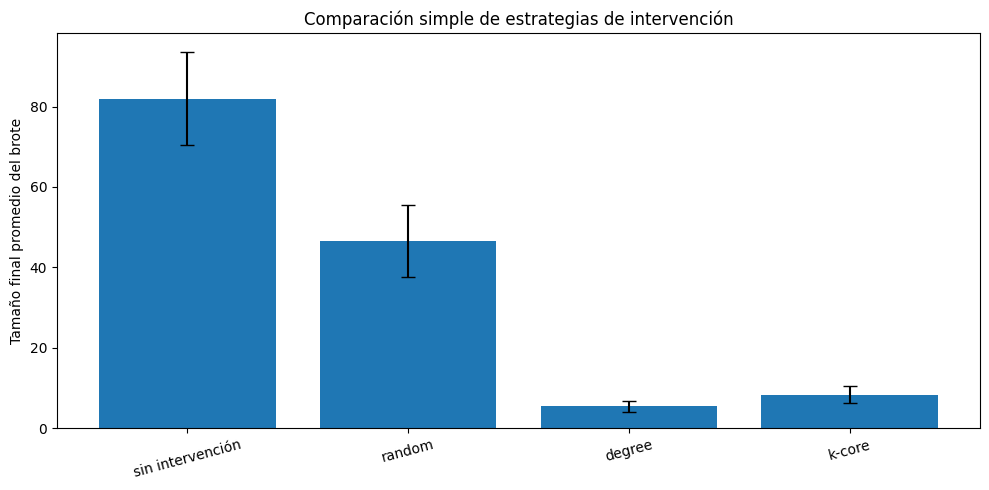

In [25]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# =========================================================
# 1. Red base
# =========================================================
np.random.seed(7)
G_ba = nx.barabasi_albert_graph(300, 4, seed=7)

# =========================================================
# 2. Simulación SIR simple
# =========================================================
def simulate_sir(G, beta=0.06, mu=0.25, seed_node=None, rng=None, max_steps=10_000):
    """
    SIR discreto simple sobre una red.
    Estados:
      S: susceptible
      I: infectado
      R: removido
    """
    rng = np.random.default_rng() if rng is None else rng

    nodes = list(G.nodes())
    if len(nodes) == 0:
        return {"final_size": 0, "S": 0, "I": 0, "R": 0, "steps": 0}

    if seed_node is None:
        seed_node = rng.choice(nodes)

    S = set(nodes)
    I = {seed_node}
    R = set()
    S.remove(seed_node)

    steps = 0

    while len(I) > 0 and steps < max_steps:
        new_I = set()
        new_R = set()

        for u in I:
            # contagio a vecinos susceptibles
            for v in G.neighbors(u):
                if v in S and rng.random() < beta:
                    new_I.add(v)

            # recuperación
            if rng.random() < mu:
                new_R.add(u)

        # actualizar estados
        newly_infected = new_I & S
        S -= newly_infected
        R |= new_R
        I = (I - new_R) | newly_infected

        steps += 1

    final_size = len(R) + len(I)   # total que pasó por infección
    return {
        "final_size": final_size,
        "S": len(S),
        "I": len(I),
        "R": len(R),
        "steps": steps
    }

# =========================================================
# 3. Estrategias de inmunización
# =========================================================
def immunize_nodes(G, nodes_to_remove):
    H = G.copy()
    H.remove_nodes_from(nodes_to_remove)
    return H

def choose_nodes_random(G, frac=0.1, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    nodes = list(G.nodes())
    k = max(1, int(frac * len(nodes)))
    return list(rng.choice(nodes, size=k, replace=False))

def choose_nodes_degree(G, frac=0.1):
    k = max(1, int(frac * G.number_of_nodes()))
    return [u for u, _ in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:k]]

def choose_nodes_kcore(G, frac=0.1):
    core = nx.core_number(G)
    k = max(1, int(frac * G.number_of_nodes()))
    return [u for u, _ in sorted(core.items(), key=lambda x: x[1], reverse=True)[:k]]

# =========================================================
# 4. Promedio del tamaño final del brote
# =========================================================
def average_final_size(G, repeats=50, beta=0.06, mu=0.25, seed=123):
    rng = np.random.default_rng(seed)
    sizes = []

    for _ in range(repeats):
        if G.number_of_nodes() == 0:
            sizes.append(0)
            continue

        seed_node = rng.choice(list(G.nodes()))
        out = simulate_sir(G, beta=beta, mu=mu, seed_node=seed_node, rng=rng)
        sizes.append(out["final_size"])

    sizes = np.array(sizes)
    return {
        "mean": sizes.mean(),
        "std": sizes.std(ddof=1),
        "se": sizes.std(ddof=1) / np.sqrt(len(sizes)),
        "all_sizes": sizes
    }

# =========================================================
# 5. Comparación de estrategias
# =========================================================
frac = 0.10
rng = np.random.default_rng(123)

strategies = {
    "sin intervención": G_ba.copy(),
    "random": immunize_nodes(G_ba, choose_nodes_random(G_ba, frac=frac, rng=rng)),
    "degree": immunize_nodes(G_ba, choose_nodes_degree(G_ba, frac=frac)),
    "k-core": immunize_nodes(G_ba, choose_nodes_kcore(G_ba, frac=frac)),
}

results = {
    name: average_final_size(H, repeats=60, beta=0.06, mu=0.25, seed=10)
    for name, H in strategies.items()
}

# Mostrar resultados numéricos
for name, out in results.items():
    print(f"{name:18s} -> mean={out['mean']:.2f}, se={out['se']:.2f}")

# =========================================================
# 6. Gráfico simple
# =========================================================
labels = list(results.keys())
means = [results[k]["mean"] for k in labels]
ses = [results[k]["se"] for k in labels]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, means, yerr=ses, capsize=5)
ax.set_title("Comparación simple de estrategias de intervención")
ax.set_ylabel("Tamaño final promedio del brote")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Cómo interpretar este experimento

Aquí inmunizamos preventivamente 10% de los nodos usando distintas estrategias. Luego simulamos muchas veces un SIR y comparamos el tamaño final promedio del brote. En esta red BA, atacar por grado o por k-core reduce mucho más el brote que inmunizar al azar.

- Esto **no prueba una ley universal**.
- Sí muestra el tipo de pregunta correcta:
  - fijar proceso,
  - fijar presupuesto de intervención,
  - comparar contra baseline,
  - promediar sobre muchas semillas y simulaciones.

Ese enfoque es metodológicamente mucho más sólido que decir "grado es mejor" o "k-core es mejor" en abstracto.

## 12. Redes temporales vs redes agregadas

Hasta ahora hemos asumido una red estática.  
Pero muchas redes reales son **temporales**: los enlaces aparecen y desaparecen en el tiempo.

Ejemplos:
- contactos cara a cara
- interacciones por mensajes
- movilidad
- transacciones

### Red agregada

La red agregada une a dos nodos si **alguna vez** interactuaron dentro de una ventana de observación.

Problema:
- mezcla eventos que no ocurrieron al mismo tiempo
- puede crear caminos "fantasma".

### Camino temporal o *time-respecting path*

Un contagio sólo puede viajar por una secuencia de enlaces si estos ocurren en orden cronológico compatible.

Eso cambia:
- accesibilidad
- velocidad efectiva
- tamaño del brote
- nodos que parecen importantes

### Entonces

> Dos nodos pueden estar conectados en la red agregada, pero **no** existir un camino temporal válido entre ellos en el periodo observado.

Por eso, cuando hay timestamps, la agregación puede sobreestimar capacidad de difusión.

## 13. Ejemplo mínimo de temporal vs agregada

Construimos una secuencia temporal de contactos y la comparamos con su red agregada.

### Error metodológico frecuente con redes temporales

Un error muy común es este:

> agregar todos los contactos, encontrar caminos en la red agregada y tratarlos como si fueran trayectorias causales de difusión.

Eso puede fallar por tres razones:

- el orden temporal puede bloquear un camino que la agregación inventa
- la ventana de observación puede mezclar episodios que nunca coexistieron
- un contacto breve o tardío puede no tener el mismo efecto que uno temprano y repetido

Si el dataset trae timestamps, la carga de la prueba está en justificar la agregación, no en asumirla por defecto.


In [26]:
import networkx as nx

# =========================================================
# Error metodológico clásico:
# la red agregada inventa caminos causales que no existen
# temporalmente.
# =========================================================

# Cada tupla es: (u, v, t)
temporal_edges = [
    (0, 1, 0),  # 0 contacta a 1 en t=0
    (2, 3, 1),  # 2 contacta a 3 en t=1  <-- ocurre demasiado temprano
    (1, 2, 3),  # 1 recién contacta a 2 en t=3
    (3, 4, 4),  # 3 contacta a 4 en t=4
]

# -----------------------------
# 1. Red agregada
# -----------------------------
G_temp_agg = nx.Graph()
G_temp_agg.add_edges_from((u, v) for u, v, t in temporal_edges)

print("=== Enlaces temporales ===")
for e in temporal_edges:
    print(e)

print("\n=== Enlaces en la red agregada ===")
print(sorted(G_temp_agg.edges()))

# -----------------------------
# 2. Accesibilidad temporal
# -----------------------------
def temporal_reachable(edges, source, start_time=0):
    """
    Devuelve el primer tiempo de llegada a cada nodo
    respetando el orden temporal de los enlaces.
    """
    reached = {source: start_time}

    # Recorremos enlaces ordenados por tiempo
    for u, v, t in sorted(edges, key=lambda x: x[2]):
        # Si ya puedo estar en u antes o en t, entonces puedo ir a v en t
        if u in reached and reached[u] <= t:
            if v not in reached:
                reached[v] = t

        # Como aquí tratamos los contactos como no dirigidos:
        # si ya puedo estar en v antes o en t, puedo ir a u en t
        if v in reached and reached[v] <= t:
            if u not in reached:
                reached[u] = t

    return reached

reach_temp = temporal_reachable(temporal_edges, source=0, start_time=0)

# -----------------------------
# 3. Accesibilidad agregada
# -----------------------------
reach_agg = nx.single_source_shortest_path_length(G_temp_agg, 0)

print("\n=== Accesibilidad temporal desde 0 ===")
print(reach_temp)

print("\n=== Accesibilidad agregada desde 0 ===")
print(reach_agg)

# -----------------------------
# 4. Comparación explícita
# -----------------------------
nodes_temp = set(reach_temp.keys())
nodes_agg = set(reach_agg.keys())

false_reachable = nodes_agg - nodes_temp

print("\n=== Nodos que la red agregada hace parecer alcanzables,")
print("=== pero que NO son temporalmente alcanzables desde 0 ===")
print(false_reachable)

# -----------------------------
# 5. Caminos agregados para ver la ilusión
# -----------------------------
print("\n=== Caminos más cortos en la red agregada desde 0 ===")
for target in sorted(nodes_agg):
    path = nx.shortest_path(G_temp_agg, 0, target)
    print(f"0 -> {target}: {path}")

=== Enlaces temporales ===
(0, 1, 0)
(2, 3, 1)
(1, 2, 3)
(3, 4, 4)

=== Enlaces en la red agregada ===
[(0, 1), (1, 2), (2, 3), (3, 4)]

=== Accesibilidad temporal desde 0 ===
{0: 0, 1: 0, 2: 3}

=== Accesibilidad agregada desde 0 ===
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}

=== Nodos que la red agregada hace parecer alcanzables,
=== pero que NO son temporalmente alcanzables desde 0 ===
{3, 4}

=== Caminos más cortos en la red agregada desde 0 ===
0 -> 0: [0]
0 -> 1: [0, 1]
0 -> 2: [0, 1, 2]
0 -> 3: [0, 1, 2, 3]
0 -> 4: [0, 1, 2, 3, 4]


In [27]:
print("""
Lectura temporal correcta:
- 0 alcanza a 1 en t=0
- 1 alcanza a 2 en t=3
- pero el contacto 2-3 ocurrió en t=1, antes de que 2 estuviera alcanzado
- por lo tanto, 3 y 4 no son alcanzables temporalmente

Lectura agregada incorrecta:
- como existen los enlaces 0-1, 1-2, 2-3 y 3-4,
  la red agregada sugiere un camino 0→4 que en realidad no respeta el tiempo
""")


Lectura temporal correcta:
- 0 alcanza a 1 en t=0
- 1 alcanza a 2 en t=3
- pero el contacto 2-3 ocurrió en t=1, antes de que 2 estuviera alcanzado
- por lo tanto, 3 y 4 no son alcanzables temporalmente

Lectura agregada incorrecta:
- como existen los enlaces 0-1, 1-2, 2-3 y 3-4,
  la red agregada sugiere un camino 0→4 que en realidad no respeta el tiempo



La red agregada inventa un camino causal de difusión porque ignora el orden temporal de los contactos. Que exista un camino topológico no implica que exista una trayectoria temporalmente válida.

En problemas reales, esta diferencia puede ser grande.  
La red agregada puede parecer muy conectada, mientras la difusión temporal real está mucho más restringida.

Esto es especialmente relevante en:
- epidemias
- movilidad
- secuencias de interacción humana
- ventanas cortas de observación

## 14. Síntesis

### Ideas claves

- Una red no sólo organiza quién está conectado con quién; también **filtra y canaliza** la dinámica.
- **`SIS`** y **`SIR`** responden preguntas distintas y no deben explicarse como si fueran intercambiables.
- El **umbral epidémico** depende del acoplamiento entre estructura y dinámica.
- **HMF** y el enfoque **espectral** ofrecen intuiciones complementarias, pero ambas son aproximaciones con supuestos.
- La equivalencia entre **`SIR`** y **percolación** es una de las ideas exactas más potentes de la unidad, siempre que respetemos su dominio de validez.
- En redes temporales, el orden de los contactos importa y la agregación puede inventar caminos causales inexistentes.
- **Importancia depende del proceso**: no hay una centralidad universal.


> En ciencia de redes, la estructura sin dinámica es incompleta; la dinámica sin estructura suele ser engañosa.


## Preguntas de autoevaluación

1. ¿Por qué dos redes con grado medio parecido pueden tener umbrales de difusión distintos?
2. ¿Cuándo esperarías que `degree` sea una mejor estrategia que `k`-core, y cuándo podría pasar lo contrario?
3. ¿Qué gana `SIR` al conectarse con percolación, y qué pierde si uno olvida que el proceso tiene tiempo?
4. ¿Qué información causal desaparece cuando conviertes contactos temporales en una red agregada?
5. Si tu objetivo fuera proteger un hospital o ralentizar una campaña de desinformación, ¿usarías la misma métrica de desempeño? ¿Por qué?


## Referencias

### Bibliografía base de la unidad

1. Newman, M. E. J. (2002). *Spread of epidemic disease on networks*. **Physical Review E**, 66, 016128.  
   DOI: https://doi.org/10.1103/PhysRevE.66.016128

2. Newman, M. E. J. (2010). *Networks: An Introduction*. Oxford University Press.  
   Editorial: https://math.bme.hu/~gabor/oktatas/SztoM/Newman_Networks.pdf 

3. Pastor-Satorras, R., & Vespignani, A. (2001). *Epidemic spreading in scale-free networks*. **Physical Review Letters**, 86(14), 3200–3203.  
   DOI: https://doi.org/10.1103/PhysRevLett.86.3200

4. Wang, Y., Chakrabarti, D., Wang, C., & Faloutsos, C. (2003). *Epidemic spreading in real networks: An eigenvalue viewpoint*. **SRDS 2003**.  
   DOI: https://doi.org/10.1109/RELDIS.2003.1238052
   PDF: https://www.cs.cmu.edu/~christos/PUBLICATIONS/srds03-virus.pdf

5. Castellano, C., & Pastor-Satorras, R. (2010). *Thresholds for epidemic spreading in networks*. **Physical Review Letters**, 105, 218701.  
   DOI: https://doi.org/10.1103/PhysRevLett.105.218701

6. Pastor-Satorras, R., Castellano, C., Van Mieghem, P., & Vespignani, A. (2015). *Epidemic processes in complex networks*. **Reviews of Modern Physics**, 87, 925–979.  
   DOI: https://doi.org/10.1103/RevModPhys.87.925

7. Holme, P. (2015). *Modern temporal network theory: a colloquium*. **The European Physical Journal B**, 88, 234.  
   DOI: https://doi.org/10.1140/epjb/e2015-60657-4

8. Holme, P. (2015). *Information content of contact-pattern representations and predictability of epidemic outbreaks*. **Scientific Reports**, 5, 14462.  
   DOI: https://doi.org/10.1038/srep14462

### Complementaria sobre influencia e intervención

9. Kitsak, M., Gallos, L. K., Havlin, S., Liljeros, F., Muchnik, L., Stanley, H. E., & Makse, H. A. (2010). *Identification of influential spreaders in complex networks*. **Nature Physics**, 6, 888–893.  
   DOI: https://doi.org/10.1038/nphys1746

10. Bramson, A., Vandermarliere, B., Shem-Tov, Y., et al. (2016). *Benchmarking Measures of Network Influence*. **Scientific Reports**, 6, 34052.  
    DOI: https://doi.org/10.1038/srep34052

11. Barabási, A.-L. (2016). *Network Science*.  
    Libro abierto: http://networksciencebook.com/

12. Easley, D., & Kleinberg, J. (2010). *Networks, Crowds, and Markets: Reasoning about a Highly Connected World*. Cambridge University Press.  
    Libro abierto: https://www.cs.cornell.edu/home/kleinber/networks-book/

13. Candia, C. (2026). *Redes y Sistemas Complejos: Monografía del curso*. Material docente.
